  1. PARAMETRI DELLE ORBITE CIRCOLARI
Quota LEO: 300.00 km | Velocita': 7.7258 km/s
Quota GEO: 35786.00 km | Velocita': 3.0747 km/s

  2. RISULTATI TRASFERIMENTO DI HOHMANN (LEO -> GEO)
Velocita' Perigeo (Tx): 10.1515 km/s
Velocita' Apogeo (Tx):  1.6078 km/s
Tempo di Volo (TOF):    5.28 ore

  3. BUDGET DELTA-V TOTALE
Delta V 1 (TLI/Perigeo): 2.4257 km/s
Delta V 2 (Circolariz.): 1.4668 km/s
DELTA V TOTALE:          3.8926 km/s


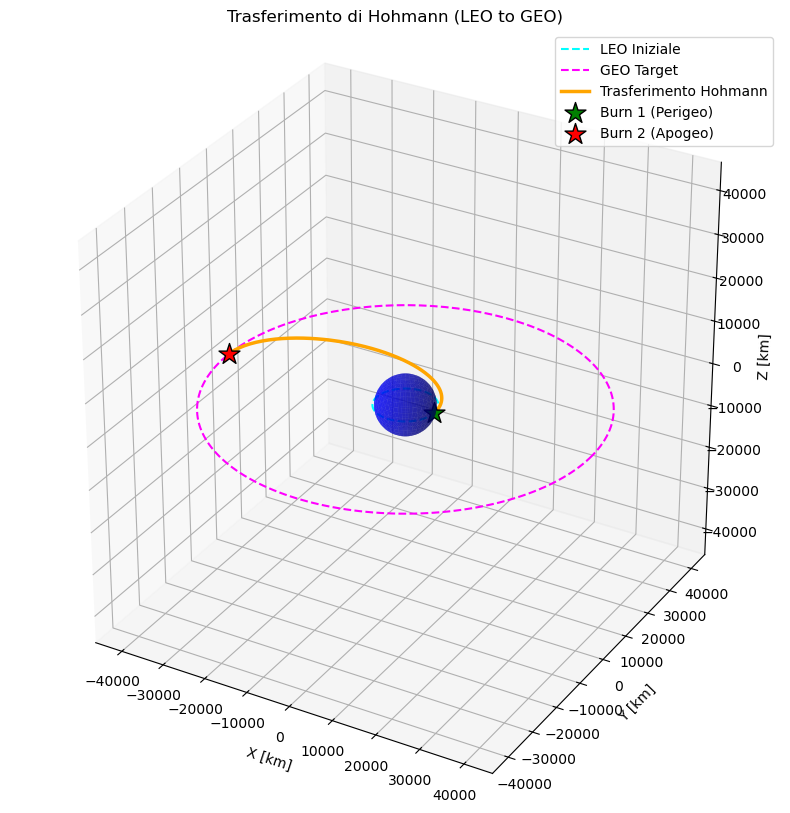

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.utils import Constants

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# ==========================================
# 2. COSTANTI FISICHE (Da Orekit, in km)
# ==========================================
mu_E = Constants.WGS84_EARTH_MU / 1e9             # Parametro gravitazionale Terrestre [km^3/s^2]
R_E = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0  # Raggio medio terrestre [km]

# ==========================================
# 3. DATI DELLE ORBITE DI PARCHEGGIO
# ==========================================
# Orbita Iniziale (LEO)
h1 = 300.0                     # Quota LEO [km]
r1 = R_E + h1                  # Raggio LEO [km]
v1 = np.sqrt(mu_E / r1)        # Velocità circolare LEO [km/s]

# Orbita Finale (GEO - Geostazionaria)
h2 = 35786.0                   # Quota GEO [km]
r2 = R_E + h2                  # Raggio GEO [km]
v2 = np.sqrt(mu_E / r2)        # Velocità circolare GEO [km/s]

print("========================================================")
print("  1. PARAMETRI DELLE ORBITE CIRCOLARI")
print("========================================================")
print(f"Quota LEO: {h1:.2f} km | Velocita': {v1:.4f} km/s")
print(f"Quota GEO: {h2:.2f} km | Velocita': {v2:.4f} km/s\n")

# ==========================================
# 4. CALCOLO TRASFERIMENTO DI HOHMANN
# ==========================================
# Geometria dell'ellisse di trasferimento
a_tx = (r1 + r2) / 2.0         # Semiasse maggiore [km]
e_tx = (r2 - r1) / (r2 + r1)   # Eccentricità

# Velocità sull'ellisse di trasferimento (Vis-Viva)
v_tx_perigeo = np.sqrt(mu_E * (2/r1 - 1/a_tx))  # Velocità all'inserzione (perigeo)
v_tx_apogeo = np.sqrt(mu_E * (2/r2 - 1/a_tx))   # Velocità all'arrivo (apogeo)

# Calcolo dei Delta-V
DeltaV_1 = v_tx_perigeo - v1   # Burn 1: Accelerazione in LEO
DeltaV_2 = v2 - v_tx_apogeo    # Burn 2: Circolarizzazione in GEO
DeltaV_Tot = DeltaV_1 + DeltaV_2

# Tempo di volo (metà periodo orbitale)
TOF_sec = np.pi * np.sqrt((a_tx**3) / mu_E)
TOF_hours = TOF_sec / 3600.0

print("========================================================")
print("  2. RISULTATI TRASFERIMENTO DI HOHMANN (LEO -> GEO)")
print("========================================================")
print(f"Velocita' Perigeo (Tx): {v_tx_perigeo:.4f} km/s")
print(f"Velocita' Apogeo (Tx):  {v_tx_apogeo:.4f} km/s")
print(f"Tempo di Volo (TOF):    {TOF_hours:.2f} ore\n")

print("========================================================")
print("  3. BUDGET DELTA-V TOTALE")
print("========================================================")
print(f"Delta V 1 (TLI/Perigeo): {DeltaV_1:.4f} km/s")
print(f"Delta V 2 (Circolariz.): {DeltaV_2:.4f} km/s")
print(f"DELTA V TOTALE:          {DeltaV_Tot:.4f} km/s")
print("========================================================")

# ==========================================
# 5. VISUALIZZAZIONE 3D DELLA MANOVRA
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Creazione array angolari
theta_orb = np.linspace(0, 2*np.pi, 200)
theta_tx = np.linspace(0, np.pi, 200)  # Mezzo giro per Hohmann

# Disegno della Terra (Scala 1:1 reale)
u_sphere, v_sphere = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
x_e = R_E * np.cos(u_sphere) * np.sin(v_sphere)
y_e = R_E * np.sin(u_sphere) * np.sin(v_sphere)
z_e = R_E * np.cos(v_sphere)
ax.plot_surface(x_e, y_e, z_e, color='blue', alpha=0.6, edgecolor='none')

# Coordinate LEO (Azzurro)
x_leo = r1 * np.cos(theta_orb)
y_leo = r1 * np.sin(theta_orb)
ax.plot(x_leo, y_leo, np.zeros_like(x_leo), color='cyan', linestyle='--', label='LEO Iniziale')

# Coordinate GEO (Magenta)
x_geo = r2 * np.cos(theta_orb)
y_geo = r2 * np.sin(theta_orb)
ax.plot(x_geo, y_geo, np.zeros_like(x_geo), color='magenta', linestyle='--', label='GEO Target')

# Coordinate Ellisse di Trasferimento (Arancione)
r_tx_plot = (a_tx * (1 - e_tx**2)) / (1 + e_tx * np.cos(theta_tx))
x_tx = r_tx_plot * np.cos(theta_tx)
y_tx = r_tx_plot * np.sin(theta_tx)
ax.plot(x_tx, y_tx, np.zeros_like(x_tx), label='Trasferimento Hohmann', color='orange', linewidth=2.5)

# Marker dei Burn
ax.scatter([x_tx[0]], [y_tx[0]], [0], color='green', s=250, marker='*', edgecolor='black', label='Burn 1 (Perigeo)', zorder=5)
ax.scatter([x_tx[-1]], [y_tx[-1]], [0], color='red', s=250, marker='*', edgecolor='black', label='Burn 2 (Apogeo)', zorder=5)

# Setup della vista grafica
ax.set_box_aspect([1,1,1]) 
lim = r2 * 1.1  # Scala basata sull'orbita GEO
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Trasferimento di Hohmann (LEO to GEO)')
ax.legend(loc='upper right')

# Salva immagine e mostra
fig.savefig('hohmann_transfer_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()